In [ ]:
from ultralytics import YOLO
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from roboflow import Roboflow

from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader
from torchvision.transforms import functional as F
from tqdm import tqdm

import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 4060 Laptop GPU



image 1/1 d:\Learning\AI_Indonesia\project_2\Object-Detection-Tracking\images\0015.jpg: 416x640 17 persons, 1 handbag, 46.2ms
Speed: 4.7ms preprocess, 46.2ms inference, 7.2ms postprocess per image at shape (1, 3, 416, 640)


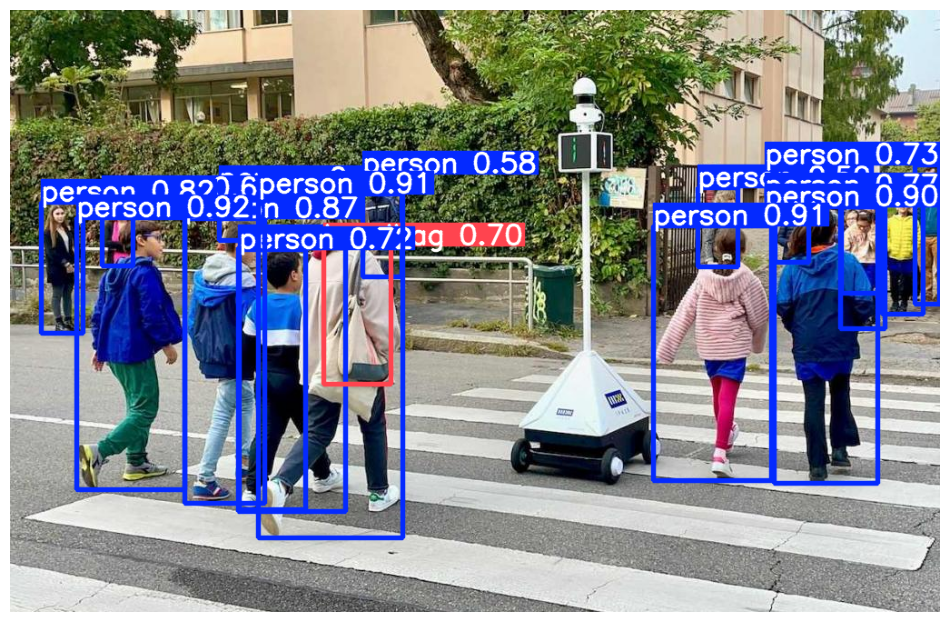

In [2]:
# Load a pre-trained YOLOv10n model
model = YOLO("yolov9s.pt")

# Perform object detection on an image
results = model("images/0015.jpg")

# Display the results
image = results[0].plot()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# langsung di Notebook
plt.figure(figsize=(12, 12))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

# Dataset

## Versi YOLO

In [ ]:
rf = Roboflow(api_key="LmLPRgcH2ELmCE79tfSz")
project = rf.workspace("leo-ueno").project("people-detection-o4rdr")
version = project.version(8)
dataset = version.download("yolov9", location="dataset_yolov9")

In [ ]:
# from my own account

rf = Roboflow(api_key="LmLPRgcH2ELmCE79tfSz")
project = rf.workspace(
    "person-tracking-undvw").project("person-tracking-ig9z0")
version = project.version(1)
dataset = version.download("yolov9", location="dataset_yolov9_custom")

# Versi Faster R-CNN

In [ ]:
rf = Roboflow(api_key="LmLPRgcH2ELmCE79tfSz")
project = rf.workspace("leo-ueno").project("people-detection-o4rdr")
version = project.version(8)
dataset = version.download("coco", location="dataset_cocojson")

# Trainig Versi YOLO

- Pada roboflow sudah dilakukan augementasi seperti 
    1. Rotate
    2. Grey scale
    3. Brightness

In [ ]:
from ultralytics import YOLO

# 1️⃣ Load model
model = YOLO("yolov9s.pt")

# 2️⃣ Train
results = model.train(
    data="dataset_yolov9/data.yaml",  # path YAML
    epochs=50,
    imgsz=640,
    batch=32,
    device=0,  # otomatis ke GPU 0
    workers=8,
    project="result_yolo",
    name="yolov9_person",
    pretrained=True,
    optimizer="Adam",
    lr0=1e-5,
)

# Training Faster R-CNN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

root_dir = "dataset_cocojson"  # folder dataset roboflow
train_dir = os.path.join(root_dir, "train")
valid_dir = os.path.join(root_dir, "valid")

train_ann = os.path.join(train_dir, "_annotations.coco.json")
valid_ann = os.path.join(valid_dir, "_annotations.coco.json")

# hanya 1 class: person (+1 background)
num_classes = 1 + 1

# =====================================================
# 2️⃣ CUSTOM COCO DATASET
# =====================================================


class CocoDataset(CocoDetection):
    def __init__(self, img_folder, ann_file):
        super().__init__(img_folder, ann_file)

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)

        # skip image tanpa anotasi
        if len(target) == 0:
            # cari index berikutnya yg punya bbox
            return self.__getitem__((idx + 1) % len(self))

        # convert image ke tensor
        img = F.to_tensor(img)
        img = F.resize(img, [480, 480])
        boxes = []
        labels = []
        for obj in target:
            xmin, ymin, w, h = obj['bbox']
            # filter bbox invalid (misal w atau h <= 0)
            if w > 0 and h > 0:
                boxes.append([xmin, ymin, xmin + w, ymin + h])
                labels.append(obj['category_id'])

        # jika semua bbox invalid, skip juga
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return img, target

